# Data Science Decision Governance: Technical Walkthrough

Full pipeline: synthetic decision-log generation, a schema contract that rejects records missing what their impact level requires, exploratory analysis, approval-speed and rollback-rate patterns by impact level, an optional logistic regression checking those patterns hold with other factors held constant, and a control chart that catches a follow-up backlog while it's happening. Companion to the [README](../README.md), which has the short version.

> All data here is synthetically generated. No proprietary data, models, or results from any employer are used or implied.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from style import set_style, style_ax, savefig, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, INK
from schema import validate_dataframe
from open_loops import monthly_on_time_rates, compute_control_chart

set_style()
%matplotlib inline

## 1. Data

900 synthetic decision records from a data science team's governance log, over a 2-year window: every model launch, experiment rollout, dashboard change, pipeline change, metric-definition change, and deprecation, each tagged with an impact level (low / medium / high), an approval lag, and two follow-up monitoring commitments due after it ships, a short check that it shipped as intended and a longer check on whether it actually worked. Impact level, artifact type, and a capacity-crunch window are the only hand-specified drivers behind approval speed, monitoring follow-through, and rollback rate; everything else is noise, generated independently of the eventual outcome the same way every other project in this repo builds its synthetic data.

In [2]:
df = pd.read_csv("../data/decision_log.csv")
IMPACT_ORDER = ["low", "medium", "high"]
df["impact_level"] = pd.Categorical(df["impact_level"], categories=IMPACT_ORDER, ordered=True)
print(f"{len(df):,} decisions, {df['proposed_date'].min()} to {df['proposed_date'].max()}")
df.head()

900 decisions, 2024-01-01 to 2025-12-30


,decision_id,artifact_type,domain_tag,impact_level,proposed_date,abandoned,approval_lag_days,approved_date,shipped_date,ship_check_required,ship_check_due,ship_check_on_time,metric_check_due,metric_check_on_time,outcome,status
0,71,dashboard_change,search_ranking,low,2025-03-09,False,1.1,2025-03-10,2025-03-16,False,NaN,NaN,2025-04-15,False,keep,closed
1,828,dashboard_change,infrastructure,low,2025-04-24,False,1.8,2025-04-26,2025-04-29,False,NaN,NaN,2025-05-29,True,rollback,reverted
2,232,pipeline_change,marketing,medium,2025-02-11,False,4.1,2025-02-15,2025-02-18,True,2025-02-25,True,2025-03-20,True,keep,closed
3,589,dashboard_change,infrastructure,low,2025-09-24,False,2.0,2025-09-26,2025-10-02,False,NaN,NaN,2025-11-01,False,keep,closed
4,40,experiment_rollout,product_analytics,medium,2025-02-10,False,3.4,2025-02-13,2025-02-17,True,2025-02-24,True,2025-03-19,True,rollback,reverted


## 2. Schema contract

Every record has to satisfy a Pydantic model (`schema.py`) before it counts as valid: a low-impact decision can't claim to need a ship check, a reverted decision has to carry a rollback outcome, an abandoned decision can't have a shipped date. This is the same role a CI schema check plays on a real pull-request-based governance repo, just run here as a batch validation instead of a per-PR gate.

In [3]:
errors = validate_dataframe(df)
print(f"Validation errors: {len(errors)} / {len(df)} records")

Validation errors: 0 / 900 records


## 3. Exploratory analysis

Dashboard and pipeline changes make up almost half the log by volume; deprecations are rarest (Figure 1). Most decisions are low impact (Figure 2), and most close out without ever being rolled back (Figure 3).

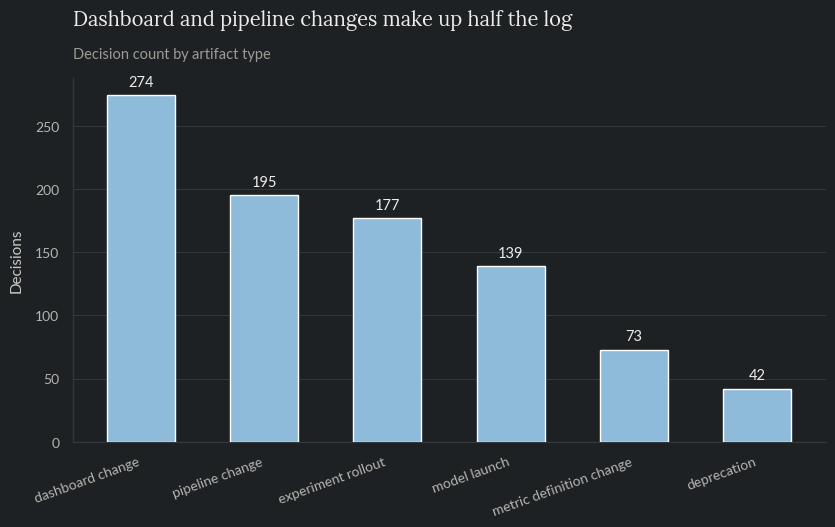

artifact_type
dashboard_change            274
pipeline_change             195
experiment_rollout          177
model_launch                139
metric_definition_change     73
deprecation                  42
Name: count, dtype: int64

In [4]:
SOURCE = f"Source: synthetic decision log (src/generate_data.py) · n = {len(df):,} decisions"

type_counts = df["artifact_type"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(type_counts.index.str.replace("_", " "), type_counts.values, color=SLATE, width=0.55, zorder=3)
for i, v in enumerate(type_counts.values):
    ax.text(i, v + len(df) * 0.008, f"{v:,}", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Dashboard and pipeline changes make up half the log",
         subtitle="Decision count by artifact type", ylabel="Decisions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
type_counts

**Figure 1.** Decision count by artifact type.

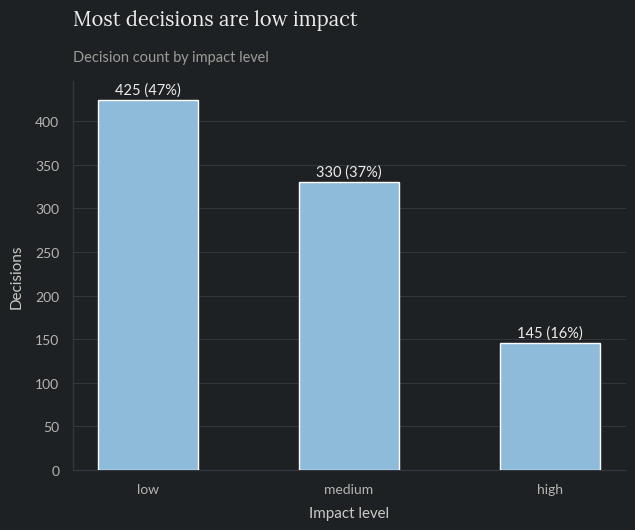

impact_level
low       0.472
medium    0.367
high      0.161
Name: count, dtype: float64

In [5]:
impact_counts = df["impact_level"].value_counts().reindex(IMPACT_ORDER)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.bar(impact_counts.index, impact_counts.values, color=SLATE, width=0.5, zorder=3)
for i, v in enumerate(impact_counts.values):
    ax.text(i, v + len(df) * 0.008, f"{v:,} ({v / len(df):.0%})", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Most decisions are low impact", subtitle="Decision count by impact level",
         xlabel="Impact level", ylabel="Decisions")
plt.tight_layout()
plt.show()
(impact_counts / len(df)).round(3)

**Figure 2.** Decision count by impact level.

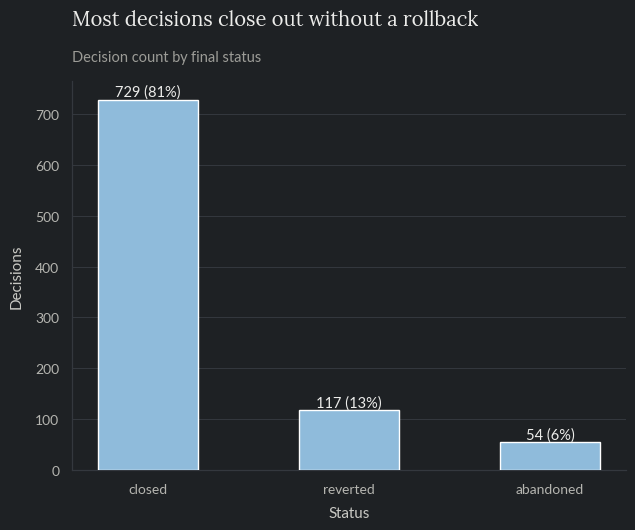

status
closed       0.81
reverted     0.13
abandoned    0.06
Name: count, dtype: float64

In [6]:
STATUS_ORDER = ["closed", "reverted", "abandoned"]
status_counts = df["status"].value_counts().reindex(STATUS_ORDER)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.bar(status_counts.index, status_counts.values, color=SLATE, width=0.5, zorder=3)
for i, v in enumerate(status_counts.values):
    ax.text(i, v + len(df) * 0.008, f"{v:,} ({v / len(df):.0%})", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Most decisions close out without a rollback", subtitle="Decision count by final status",
         xlabel="Status", ylabel="Decisions")
plt.tight_layout()
plt.show()
(status_counts / len(df)).round(3)

**Figure 3.** Decision count by final status.

6% of decisions never get approved at all. That's not noise, it rises with impact level: bigger changes are harder to get everyone to agree to, so they stall more often before ever shipping.

## 4. Approval speed and rollback rate, by impact level

Two questions: does more scrutiny before shipping actually slow things down, and does it pay off afterward? Both charts below say yes.

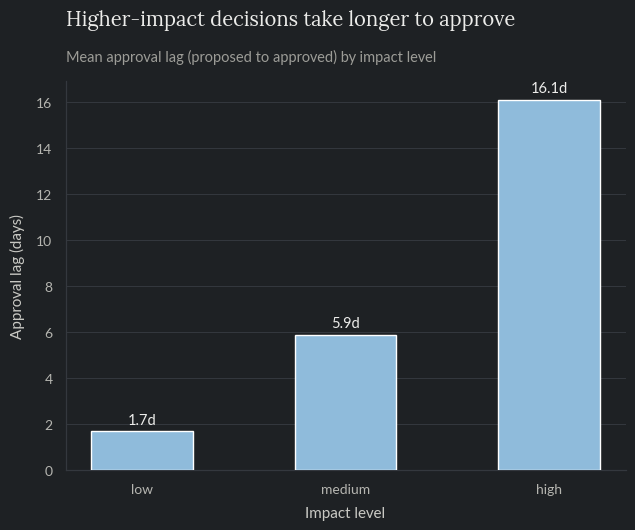

impact_level
low        1.68
medium     5.86
high      16.08
Name: approval_lag_days, dtype: float64

In [7]:
lag = df.groupby("impact_level", observed=True)["approval_lag_days"].mean().reindex(IMPACT_ORDER)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.bar(lag.index, lag.values, color=SLATE, width=0.5, zorder=3)
for i, v in enumerate(lag.values):
    ax.text(i, v + lag.max() * 0.02, f"{v:.1f}d", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Higher-impact decisions take longer to approve",
         subtitle="Mean approval lag (proposed to approved) by impact level",
         xlabel="Impact level", ylabel="Approval lag (days)")
plt.tight_layout()
plt.show()
lag.round(2)

**Figure 4.** Mean approval lag by impact level.

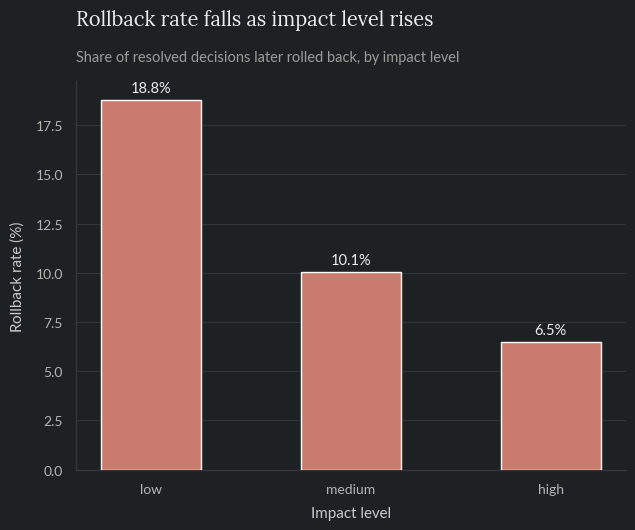

impact_level
low       0.188
medium    0.101
high      0.065
Name: outcome, dtype: float64

In [8]:
resolved = df[df["status"].isin(["closed", "reverted"])]
rate = resolved.groupby("impact_level", observed=True)["outcome"].apply(lambda s: (s == "rollback").mean()).reindex(IMPACT_ORDER)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.bar(rate.index, rate.values * 100, color=MUTED_RED, width=0.5, zorder=3)
for i, v in enumerate(rate.values):
    ax.text(i, v * 100 + 0.4, f"{v:.1%}", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Rollback rate falls as impact level rises",
         subtitle="Share of resolved decisions later rolled back, by impact level",
         xlabel="Impact level", ylabel="Rollback rate (%)")
plt.tight_layout()
plt.show()
rate.round(3)

**Figure 5.** Rollback rate by impact level, resolved decisions only.

Low-impact decisions get rolled back almost 3x as often as high-impact ones (18.8% vs. 6.5%). That's the review process working as intended: the decisions that get the most scrutiny before shipping are the ones least likely to need undoing afterward.

## 5. Optional check: does this hold with everything else in the same model?

The two charts above look at one factor at a time. A small logistic regression predicting rollback from impact level, artifact type, and approval lag together checks whether impact level is still doing real work once the other factors are in the picture, or whether it was just standing in for something else.

In [9]:
resolved = resolved.copy()
resolved["rollback"] = (resolved["outcome"] == "rollback").astype(int)

X = pd.get_dummies(resolved[["impact_level", "artifact_type"]], drop_first=True)
X["approval_lag_days"] = resolved["approval_lag_days"].values
feature_names = X.columns.tolist()
y = resolved["rollback"].values

X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train_s, y_train)
pr_auc = average_precision_score(y_test, model.predict_proba(X_test_s)[:, 1])
print(f"PR-AUC: {pr_auc:.3f} (base rate {y_test.mean():.3f})")

PR-AUC: 0.186 (base rate 0.137)


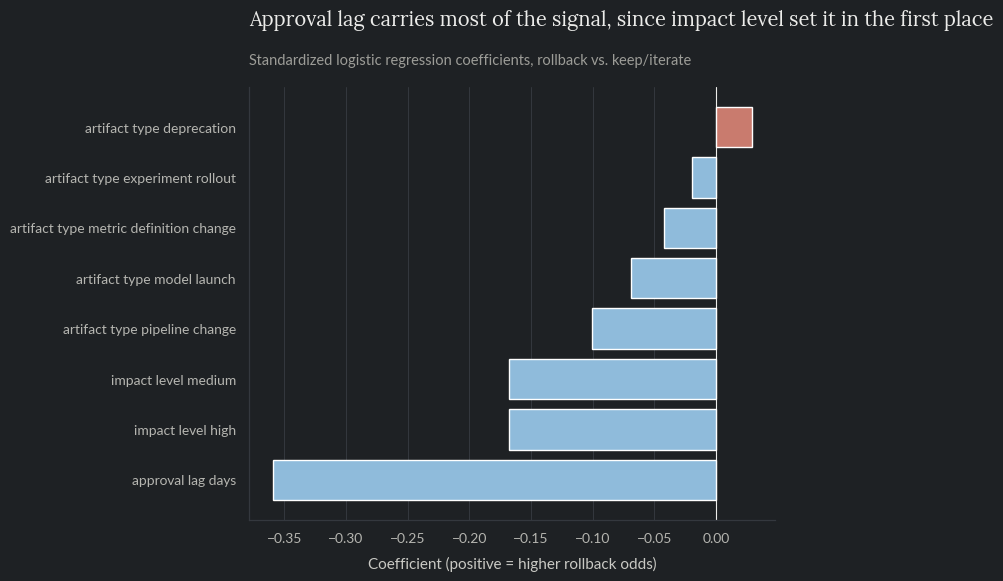

approval_lag_days                        -0.359
impact_level_high                        -0.168
impact_level_medium                      -0.168
artifact_type_pipeline_change            -0.101
artifact_type_model_launch               -0.069
artifact_type_metric_definition_change   -0.042
artifact_type_experiment_rollout         -0.020
artifact_type_deprecation                 0.029
dtype: float64

In [10]:
coefs = pd.Series(model.coef_[0], index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = [MUTED_RED if c > 0 else SLATE for c in coefs.values]
ax.barh(coefs.index.str.replace("_", " "), coefs.values, color=colors, zorder=3)
ax.axvline(0, color=INK, linewidth=0.8)
style_ax(ax, title="Approval lag carries most of the signal, since impact level set it in the first place",
         subtitle="Standardized logistic regression coefficients, rollback vs. keep/iterate",
         xlabel="Coefficient (positive = higher rollback odds)", grid_axis="x")
plt.tight_layout()
plt.show()
coefs.round(3)

**Figure 6.** Standardized logistic regression coefficients, rollback vs. keep/iterate.

Two things worth separating here. First, direction: every impact-level and artifact-type coefficient points the way Figures 4 and 5 predicted, medium and high impact both push rollback odds down, so the pattern holds up even with several variables competing for credit at once. Second, size: PR-AUC only reaches 0.19 against a 13.7% base rate, and impact level alone (no artifact type, no approval lag) gets almost the same PR-AUC on its own. Approval lag ends up with the largest single coefficient, but that's because it's set almost directly by impact level in this simulation, not because it's an independent driver, the two are standing in for the same thing rather than adding new information. That's an honest limit of the exercise: this simulation only makes rollback probability a function of impact level, so no combination of these fields will predict any single decision's fate reliably. Aggregate differences (Figures 4 and 5) can be real and large while sample-level predictability stays low, and that's exactly what shows up here.

## 6. Catching a follow-up backlog before it becomes a habit

The metric check (30 days after shipping: did it actually work) is the more consequential of the two follow-up commitments, and it's also the one most likely to slip. A monthly control chart on the on-time rate, the same p-chart approach project 04 uses for a quality regression, flags a sustained dip rather than reacting to single-month noise.

In [11]:
on_time_by_impact = df.dropna(subset=["metric_check_on_time"]).assign(
    metric_check_on_time=lambda d: d["metric_check_on_time"].astype("boolean")
).groupby("impact_level", observed=True)["metric_check_on_time"].mean().reindex(IMPACT_ORDER)
print("Metric-check on-time rate by impact level:")
on_time_by_impact.round(3)

Metric-check on-time rate by impact level:


impact_level
low       0.516
medium    0.734
high      0.886
Name: metric_check_on_time, dtype: Float64

Low-impact decisions get followed up on barely half the time (51.6%), against 88.6% for high-impact ones. Nobody's skipping the review meeting for a big model launch; a small dashboard tweak is exactly the kind of thing that quietly falls off everyone's list.

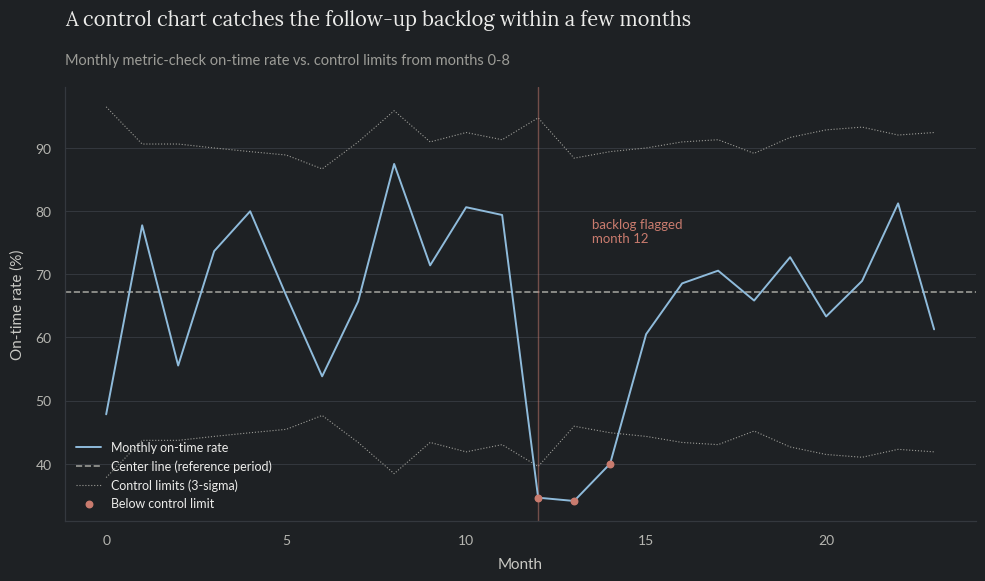

Center line: 67.2% | Months below control limit: 3 / 24 | Backlog flagged starting month 12


In [12]:
monthly = monthly_on_time_rates(df)
result = compute_control_chart(monthly)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(result["months"], result["rates"] * 100, color=SLATE, linewidth=1.4, zorder=3, label="Monthly on-time rate")
ax.axhline(result["center"] * 100, color=GREY, linewidth=1.2, ls="--", label="Center line (reference period)")
ax.plot(result["months"], result["ucl"] * 100, color=GREY, linewidth=0.8, ls=":")
ax.plot(result["months"], result["lcl"] * 100, color=GREY, linewidth=0.8, ls=":", label="Control limits (3-sigma)")
alert_months = result["months"][result["out_of_control"]]
alert_rates = result["rates"][result["out_of_control"]] * 100
ax.scatter(alert_months, alert_rates, color=MUTED_RED, s=22, zorder=4, label="Below control limit")
if result["detected_month"] is not None:
    ax.axvline(result["detected_month"], color=MUTED_RED, linewidth=1, ls="-", alpha=0.5)
    ax.annotate(f"backlog flagged\nmonth {result['detected_month']}",
                xy=(result["detected_month"], result["center"] * 100),
                xytext=(result["detected_month"] + 1.5, result["center"] * 100 + 8),
                fontsize=9.5, color=MUTED_RED)
style_ax(ax, title="A control chart catches the follow-up backlog within a few months",
         subtitle="Monthly metric-check on-time rate vs. control limits from months 0-8",
         xlabel="Month", ylabel="On-time rate (%)")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()
print(f"Center line: {result['center']:.1%} | Months below control limit: {int(result['out_of_control'].sum())} / {len(monthly)} "
      f"| Backlog flagged starting month {result['detected_month']}")

**Figure 7.** Monthly metric-check on-time rate vs. control limits from the reference period.

Months 12-14 drop well below the lower control limit and stay there for three straight months, exactly the run-rule threshold needed to flag a sustained problem instead of one noisy month. In this simulation that dip is a stand-in for a team running short on review capacity for a stretch; a real version of this chart would be the first signal that follow-up checks are backing up, well before anyone manually notices a pile of overdue decisions.

## 7. Takeaways

Where the review process is working: rollback rate falls sharply with impact level (18.8% down to 6.5%), and that relationship survives being checked alongside artifact type and approval speed in the same model.

Where it isn't: monitoring follow-through runs the opposite direction. Low-impact decisions, the ones that skip the extra review, are also the ones most likely to never get checked on afterward (51.6% on-time vs. 88.6% for high impact). The things nobody was worried about at ship time are exactly the ones nobody follows up on later, which is a bad combination if any of them turn out to matter.

A monthly control chart on the on-time rate (Figure 7) catches a sustained backlog within a few months instead of it surfacing as a vague sense that "a lot of things seem to be overdue." That's a cheap, mechanical check worth having regardless of how the review process itself is tuned.

## 8. Limitations

- Synthetic data with hand-specified, largely independent drivers (impact level sets approval speed, abandonment, monitoring follow-through, and rollback rate directly). A real governance log would have messier, more entangled causes: team workload, who's on vacation, how well-understood the artifact type is, whether a similar decision recently went wrong.
- The logistic regression bonus is deliberately modest in scope, interpretability over predictive power, and the write-up says so rather than overstating what a PR-AUC of 0.19 supports.
- Impact level here is treated as already assigned. A real system also has to solve how a change gets classified in the first place, which is its own judgment call, not something this dataset models.